#  Survival Analysis
## GBSG Breast Cancer Study Group Dataset
###  Project Overview

This project series performs a **clinical survival analysis** on the German Breast Cancer Study Group (GBSG2) dataset using the Python `lifelines` library. The goal is to model and interpret **time-to-event outcomes** ,specifically, how long patients remain recurrence-free, and which clinical factors influence that survival time.

###  About the GBSG2 Dataset

The dataset comes from a **randomised clinical trial (1984–1989)** on 686 women with node-positive breast cancer, conducted by the German Breast Cancer Study Group.

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from lifelines.datasets import load_gbsg2
import warnings
warnings.filterwarnings("ignore")

# Plotting style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)

print(" Libraries imported successfully")

 Libraries imported successfully


---
## 1. Load the Dataset

In [3]:
# Load the GBSG2 dataset directly from the lifelines library
df = load_gbsg2()

print(f"Dataset shape: {df.shape[0]} patients × {df.shape[1]} columns\n")
df.head()

Dataset shape: 686 patients × 10 columns



,horTh,age,menostat,tsize,tgrade,pnodes,progrec,estrec,time,cens
0,no,70,Post,21,II,3,48,66,1814,1
1,yes,56,Post,12,II,7,61,77,2018,1
2,yes,58,Post,35,II,9,52,271,712,1
3,yes,59,Post,17,II,4,60,29,1807,1
4,no,73,Post,35,II,1,26,65,772,1


---
## 2. Basic Inspection

In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 686 entries, 0 to 685
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   horTh     686 non-null    object
 1   age       686 non-null    int64 
 2   menostat  686 non-null    object
 3   tsize     686 non-null    int64 
 4   tgrade    686 non-null    object
 5   pnodes    686 non-null    int64 
 6   progrec   686 non-null    int64 
 7   estrec    686 non-null    int64 
 8   time      686 non-null    int64 
 9   cens      686 non-null    int64 
dtypes: int64(7), object(3)
memory usage: 53.7+ KB


In [5]:
# Statistical summary for numeric columns
df.describe(include="all").round(2)

,horTh,age,menostat,tsize,tgrade,pnodes,progrec,estrec,time,cens
count,686,686.00,686,686.00,686,686.00,686.00,686.00,686.00,686.00
unique,2,NaN,2,NaN,3,NaN,NaN,NaN,NaN,NaN
top,no,NaN,Post,NaN,II,NaN,NaN,NaN,NaN,NaN
freq,440,NaN,396,NaN,444,NaN,NaN,NaN,NaN,NaN
mean,NaN,53.05,NaN,29.33,NaN,5.01,110.00,96.25,1124.49,0.44
std,NaN,10.12,NaN,14.30,NaN,5.48,202.33,153.08,642.79,0.50
min,NaN,21.00,NaN,3.00,NaN,1.00,0.00,0.00,8.00,0.00
25%,NaN,46.00,NaN,20.00,NaN,1.00,7.00,8.00,567.75,0.00
50%,NaN,53.00,NaN,25.00,NaN,3.00,32.50,36.00,1084.00,0.00
75%,NaN,61.00,NaN,35.00,NaN,7.00,131.75,114.00,1684.75,1.00


In [6]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing >= 0])  # Show all

if missing.sum() == 0:
    print("\n No missing values found — no imputation required.")

Missing values per column:
horTh       0
age         0
menostat    0
tsize       0
tgrade      0
pnodes      0
progrec     0
estrec      0
time        0
cens        0
dtype: int64

 No missing values found — no imputation required.


---
## 3. Outcome Variable Analysis

The two most important columns in any survival dataset are:
- **`time`**: duration of follow-up (in days)
- **`cens`**: whether the event (recurrence/death) was observed (1) or censored (0)

In [7]:
# Event rate
event_counts = df["cens"].value_counts()
event_rate = df["cens"].mean() * 100

print("Event (cens) distribution:")
print(event_counts.rename({1: "Event observed (1)", 0: "Censored (0)"}))
print(f"\nEvent rate: {event_rate:.1f}%  |  Censoring rate: {100 - event_rate:.1f}%")

Event (cens) distribution:
cens
Censored (0)          387
Event observed (1)    299
Name: count, dtype: int64

Event rate: 43.6%  |  Censoring rate: 56.4%


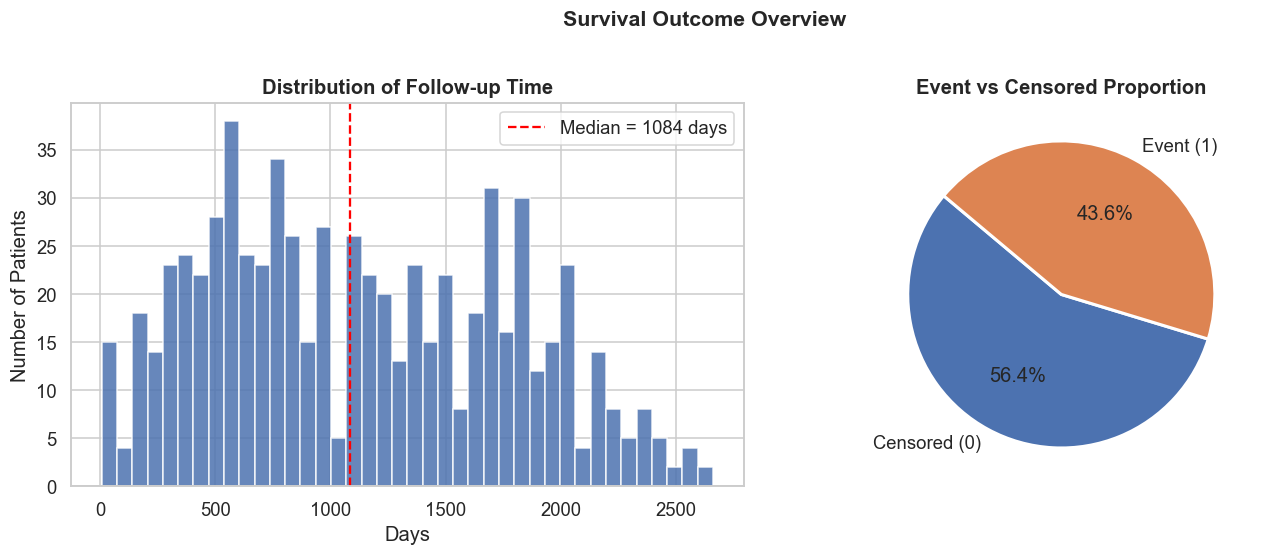

 Plot saved under outputs/figures/


<Figure size 1100x550 with 0 Axes>

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Follow-up time distribution ---
axes[0].hist(df["time"], bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].set_title("Distribution of Follow-up Time", fontweight="bold")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Number of Patients")
median_time = df["time"].median()
axes[0].axvline(median_time, color="red", linestyle="--", linewidth=1.5,
                label=f"Median = {median_time:.0f} days")
axes[0].legend()

# --- Event vs Censored ---
colors = ["#4C72B0", "#DD8452"]
labels = ["Censored (0)", "Event (1)"]
axes[1].pie(event_counts.sort_index(), labels=labels, colors=colors,
            autopct="%1.1f%%", startangle=140,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Event vs Censored Proportion", fontweight="bold")

plt.suptitle("Survival Outcome Overview", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
plt.savefig(
    "outputs/figures/Event_vs_Censored_Proportion.png",
    dpi=300,
    bbox_inches="tight"
)


print(" Plot saved under outputs/figures/")

---
## 4. Clinical Feature Distributions

Let's examine the spread of each clinical predictor, separated by outcome
to get an early sense of which features might be prognostic.

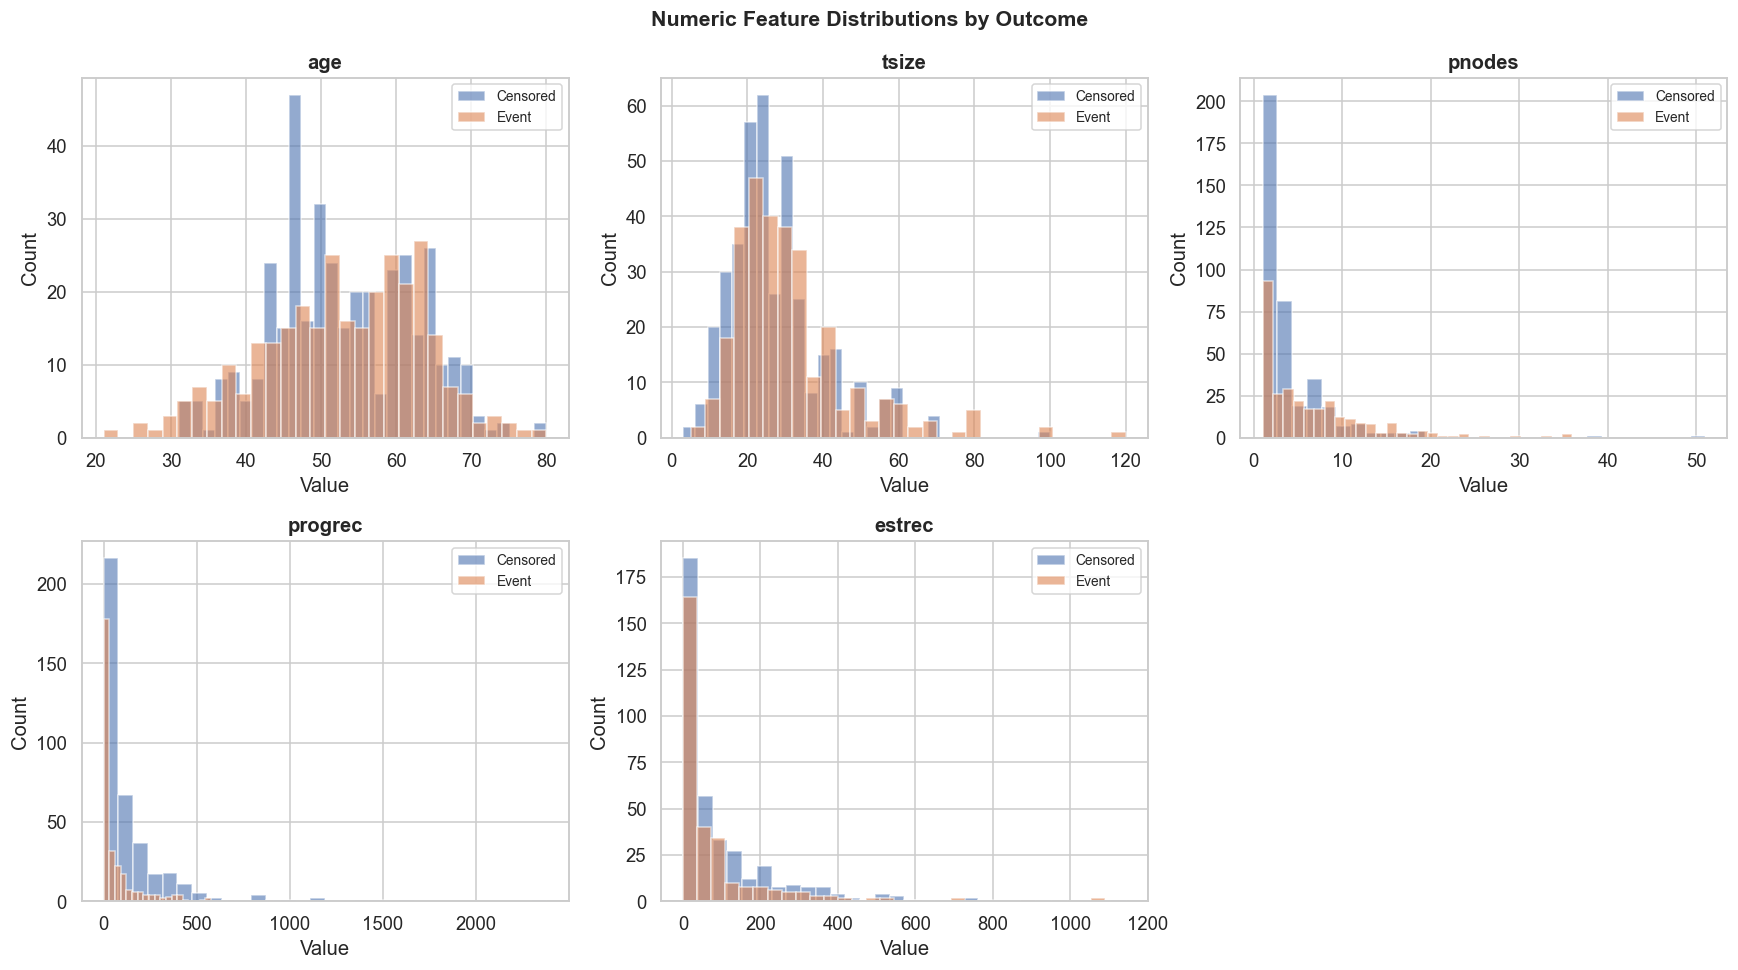

 Plot saved under outputs/figures/


<Figure size 1100x550 with 0 Axes>

In [9]:
numeric_cols = ["age", "tsize", "pnodes", "progrec", "estrec"]
cat_cols = ["horTh", "menostat", "tgrade"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for event_val, label, color in [(0, "Censored", "#4C72B0"), (1, "Event", "#DD8452")]:
        axes[i].hist(df.loc[df["cens"] == event_val, col],
                     bins=30, alpha=0.6, label=label, color=color, edgecolor="white")
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=9)

# Remove unused subplot
axes[5].axis("off")

plt.suptitle("Numeric Feature Distributions by Outcome", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

plt.savefig(
    "outputs/figures/Numeric_Feature_Distributions_by_Outcome.png",
    dpi=300,
    bbox_inches="tight"
)


print(" Plot saved under outputs/figures/")

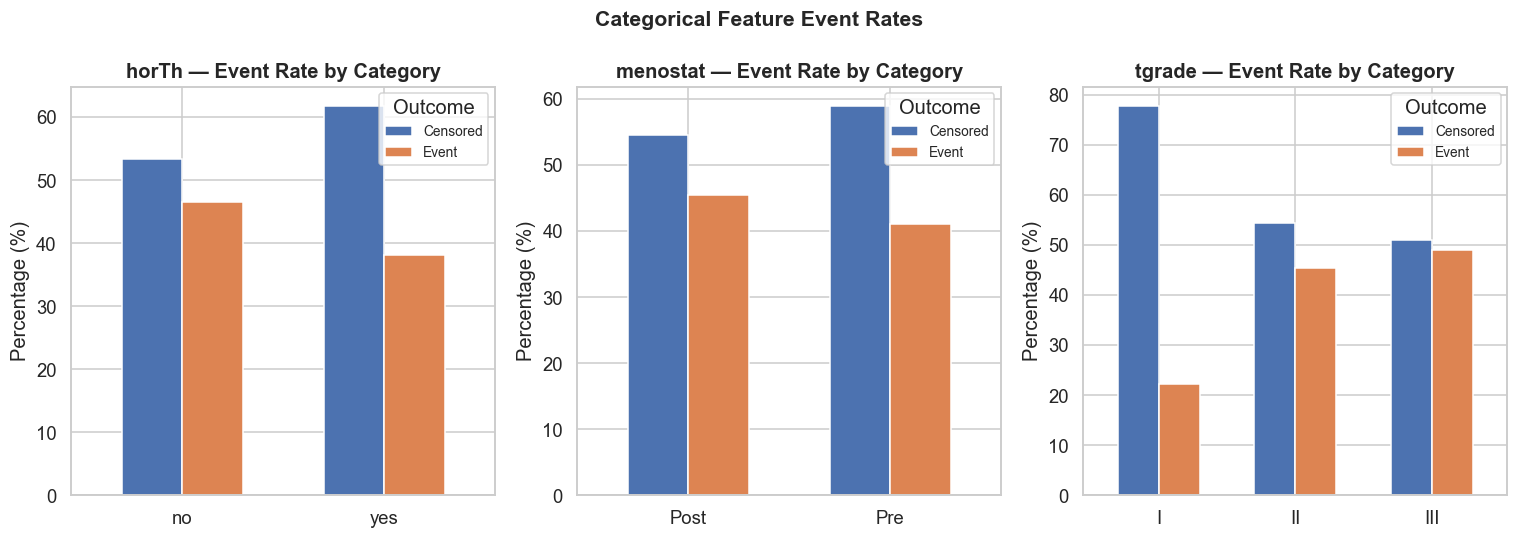

 Plot saved under outputs/figures/


<Figure size 1100x550 with 0 Axes>

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df["cens"], normalize="index") * 100
    ct.columns = ["Censored", "Event"]
    ct.plot(kind="bar", ax=axes[i], color=["#4C72B0", "#DD8452"],
            edgecolor="white", width=0.6)
    axes[i].set_title(f"{col} — Event Rate by Category", fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Percentage (%)")
    axes[i].tick_params(axis="x", rotation=0)
    axes[i].legend(title="Outcome", fontsize=9)

plt.suptitle("Categorical Feature Event Rates", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
plt.savefig(
    "outputs/figures/Categorical_Feature_Event_Rates.png",
    dpi=300,
    bbox_inches="tight"
)


print(" Plot saved under outputs/figures/")

---
## 5. Correlation & Multicollinearity Check

Before modelling, we should examine correlations between numeric predictors.
Highly correlated features can destabilise Cox model coefficient estimates.

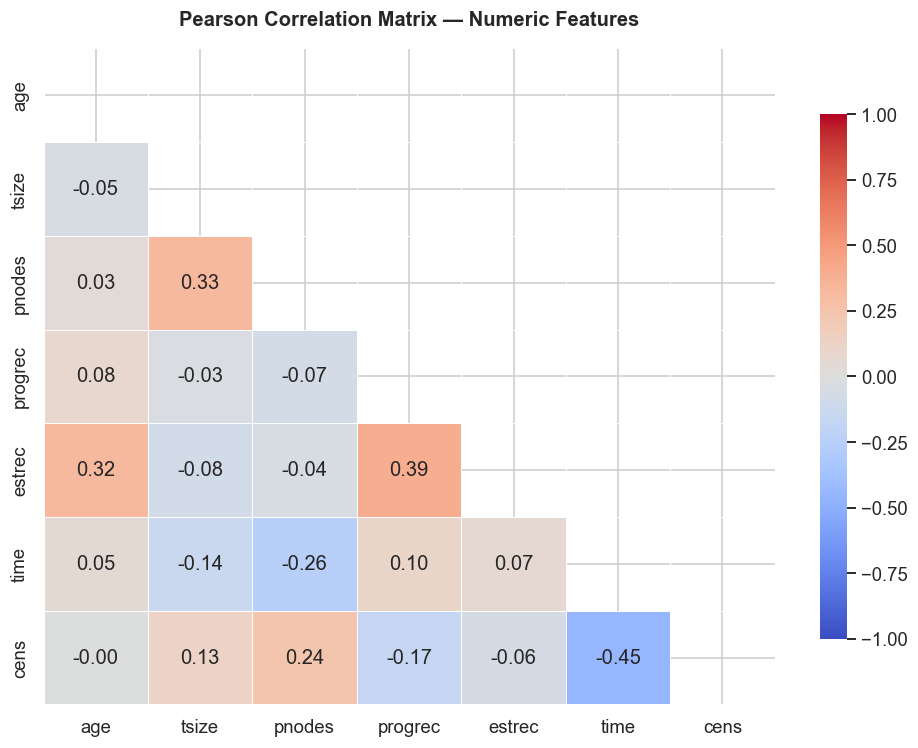

 Plot saved under outputs/figures/

💡 Note: progrec and estrec show moderate positive correlation (expected — both
   are hormone receptor measurements). We'll keep both but monitor in modelling.


<Figure size 1100x550 with 0 Axes>

In [11]:
corr = df[numeric_cols + ["time", "cens"]].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, ax=ax,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Pearson Correlation Matrix — Numeric Features", fontweight="bold", pad=15)
plt.tight_layout()
plt.show()
plt.savefig(
    "outputs/figures/Pearson_Correlation_Matrix_Numeric_Features.png",
    dpi=300,
    bbox_inches="tight"
)


print(" Plot saved under outputs/figures/")

print("\n💡 Note: progrec and estrec show moderate positive correlation (expected — both")
print("   are hormone receptor measurements). We'll keep both but monitor in modelling.")

---
## 6. Feature Engineering & Encoding

The Cox model in `lifelines` requires all covariates to be numeric.
We encode the categorical variables and engineer a useful age-group feature.

In [13]:
df_model = df.copy()

# --- Binary encoding ---
df_model["horTh_enc"]    = (df_model["horTh"] == "yes").astype(int)
df_model["menostat_enc"] = (df_model["menostat"] == "Post").astype(int)

# --- Ordinal encoding for tumour grade (I=1, II=2, III=3) ---
grade_map = {"I": 1, "II": 2, "III": 3}
df_model["tgrade_enc"] = df_model["tgrade"].map(grade_map)

# --- Age group feature ---
df_model["age_group"] = pd.cut(
    df_model["age"],
    bins=[0, 45, 55, 65, 100],
    labels=["<45", "45–55", "55–65", "65+"]
)

# --- Log-transform skewed receptor columns ---
# progrec and estrec are right-skewed; log1p stabilises variance
df_model["log_progrec"] = np.log1p(df_model["progrec"])
df_model["log_estrec"]  = np.log1p(df_model["estrec"])

print("Encoded columns added. Preview:")
df_model[["horTh_enc", "menostat_enc", "tgrade_enc", "age_group",
          "log_progrec", "log_estrec"]].head()

Encoded columns added. Preview:


,horTh_enc,menostat_enc,tgrade_enc,age_group,log_progrec,log_estrec
0,0,1,2,65+,3.891820,4.204693
1,1,1,2,55–65,4.127134,4.356709
2,1,1,2,55–65,3.970292,5.605802
3,1,1,2,55–65,4.110874,3.401197
4,0,1,2,65+,3.295837,4.189655


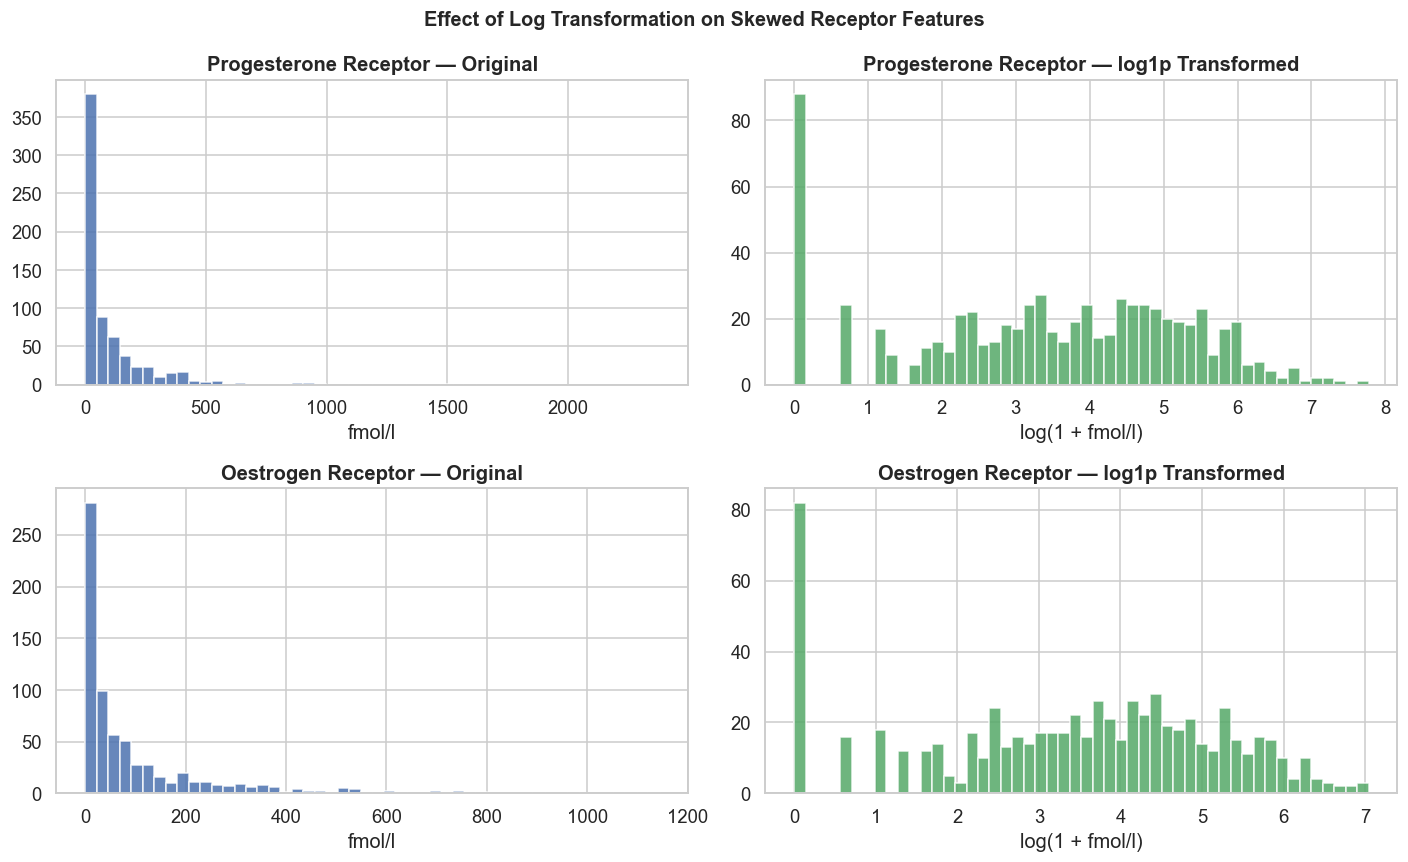

 Plot saved under outputs/figures/


<Figure size 1100x550 with 0 Axes>

In [14]:
# Visualise log transformation effect on receptor columns
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for j, (orig, log_col, label) in enumerate([
    ("progrec", "log_progrec", "Progesterone Receptor"),
    ("estrec",  "log_estrec",  "Oestrogen Receptor"),
]):
    axes[j, 0].hist(df_model[orig], bins=50, color="#4C72B0", edgecolor="white", alpha=0.85)
    axes[j, 0].set_title(f"{label} — Original", fontweight="bold")
    axes[j, 0].set_xlabel("fmol/l")

    axes[j, 1].hist(df_model[log_col], bins=50, color="#55A868", edgecolor="white", alpha=0.85)
    axes[j, 1].set_title(f"{label} — log1p Transformed", fontweight="bold")
    axes[j, 1].set_xlabel("log(1 + fmol/l)")

plt.suptitle("Effect of Log Transformation on Skewed Receptor Features",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
plt.savefig(
    "outputs/figures/Effect_of_Log_Transformation.png",
    dpi=300,
    bbox_inches="tight"
)


print(" Plot saved under outputs/figures/")

---
## 7. Save Prepared Dataset

In [15]:
# Save prepared data for use in subsequent notebooks
df_model.to_csv("gbsg2_prepared.csv", index=False)
print("✅ Saved: gbsg2_prepared.csv")
print(f"   Shape: {df_model.shape}")
print(f"   Columns: {list(df_model.columns)}")

✅ Saved: gbsg2_prepared.csv
   Shape: (686, 16)
   Columns: ['horTh', 'age', 'menostat', 'tsize', 'tgrade', 'pnodes', 'progrec', 'estrec', 'time', 'cens', 'horTh_enc', 'menostat_enc', 'tgrade_enc', 'age_group', 'log_progrec', 'log_estrec']


---
## ✅ Notebook 1 Summary

| Step | Finding |
|------|---------|
| Dataset size | 686 patients, 10 clinical variables |
| Missing values | None — no imputation needed |
| Event rate | ~43.9% of patients experienced recurrence/death |
| Median follow-up | ~1084 days (~3 years) |
| Key observation | Higher `pnodes`, larger `tsize`, and grade III tumours trend toward higher event rates |
| Skewness | `progrec` and `estrec` are right-skewed; log-transformed for modelling |
| Encoding | `horTh`, `menostat` binary-encoded; `tgrade` ordinally encoded |

